### Import Necessary Libraries

In [70]:
import os
import json
from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field, ValidationError
from typing import List, Optional, Dict
from datetime import date
import time
from tqdm import tqdm
import pandas as pd
from datasets import load_dataset
from pydantic import BaseModel, Field
import re
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

# Load environment variables from .env file
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
# groq_key = os.getenv("GROQ_API_KEY")

client = None
if not api_key:
    print("⚠️ Set GEMINI_API_KEY in environment or a .env file")
else:
    # Configure the OpenAI client to point to Google's endpoint
    client = OpenAI(
        api_key=api_key,
        base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
    )
    print("✅ OpenAI client configured for Gemini.")

# if not groq_key:
#     print("⚠️ Set GROQ_API_KEY in environment or a .env file")
# else:
#     # Configure Groq client (Llama 3.1 70B model)
#     client = Groq(api_key=groq_key)
#     print("✅ Groq client configured (Llama3 70B via Groq).")

✅ OpenAI client configured for Gemini.


### 1. Introduction

This is a quick assignment to try out some of the methods we worked on in this module. Our goal is to experiment with the pipeline and build a foundation for our discussion during the exam. We analyze S&P 500 earnings call transcripts to explore key topics discussed by companies using an LLM-based pipeline.

***Objectives***

We use an LLM combined with network analysis on a real text corpus. Our objectives are as follows:
1. Extract structured information from text using an LLM.
2. Explore it with basic descriptive statistics.
3. Build a knowledge graph or network from the extracted information.
4. Analyze the resulting network to uncover interesting patterns.

### 2. Data Loading and Sampling

The dataset used in this study was obtained from Hugging Face (Kurry, 2024), containing S&P 500 and US large-cap earnings call transcripts from 2023 to 2025. 

Here, we sample 500 transcripts for manageability. Each row represents one earnings call with fields like `content`, `structured_content`, `company_name`, and `year`.


In [ ]:
# 🧠 Load and Prepare Data

# 1️⃣ Load dataset from Hugging Face
earnings = load_dataset("kurry/sp500_earnings_transcripts", split="train")

# 2️⃣ Convert to pandas DataFrame
df_raw = earnings.to_pandas()
print(f"Total rows in full dataset: {len(df_raw):,}")

# 3️⃣ Filter for years 2023–2025
df_period = df_raw[df_raw["year"].between(2023, 2025)].copy()
print(f"Rows after filtering (2023–2025): {len(df_period):,}")

# 4️⃣ Sample only rows with valid company_name & company_id (non-missing)
print("Missing values per column:")
print(df_period.isna().sum())

df = (df_period[df_period["company_name"].notna() & df_period["company_id"].notna()]
    .sample(n=500, random_state=42)
    .reset_index(drop=True))

print('Missing values per column after filtering:')
print(df.isna().sum())
df.head()

Total rows in full dataset: 33,362
Rows after filtering (2023–2025): 4,759
Missing values per column:
symbol                  0
quarter                 0
year                    0
date                    0
content                 0
structured_content      0
company_name          209
company_id            209
dtype: int64
Missing values per column after filtering:
symbol                0
quarter               0
year                  0
date                  0
content               0
structured_content    0
company_name          0
company_id            0
dtype: int64


,symbol,quarter,year,date,content,structured_content,company_name,company_id
0,BAC,1,2024,2024-04-16 08:30:00,Operator: Good day everyone and welcome to the...,"[{'speaker': 'Operator', 'text': 'Good day eve...",Bank of America Corporation,19049.0
1,LIN,2,2023,2023-07-27 09:00:00,"Operator: Ladies and gentlemen, good day, and ...","[{'speaker': 'Operator', 'text': 'Ladies and g...",Linde plc,318049.0
2,ABBV,4,2024,2025-01-31 03:00:00,Operator: Good morning and thank you for stand...,"[{'speaker': 'Operator', 'text': 'Good morning...",AbbVie Inc.,141885706.0
3,TEL,3,2023,2023-07-26 08:30:00,"Operator: Ladies and gentlemen good morning, a...","[{'speaker': 'Operator', 'text': 'Ladies and g...",TE Connectivity plc,8106523.0
4,AES,1,2023,2023-05-05 10:00:00,Operator: Good morning. Thank you for attendin...,"[{'speaker': 'Operator', 'text': 'Good morning...",The AES Corporation,35312.0


### 3. Data Processing


In [72]:
# 5️⃣ Clean the transcript text

def clean_text(text):
    # remove speaker labels like Operator:, Executives:, Analyst:
    text = re.sub(r'\b(Operator|Executives?|Analyst|Coordinator|Speaker|Host):\s*', '', text)
    # remove extra spaces and line breaks
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_content"] = df["content"].apply(clean_text)
    
df_llm = df[["company_name", "year", "clean_content"]]
df_llm.head()

,company_name,year,clean_content
0,Bank of America Corporation,2024,Good day everyone and welcome to the Bank of A...
1,Linde plc,2023,"Ladies and gentlemen, good day, and thank you ..."
2,AbbVie Inc.,2024,Good morning and thank you for standing by. We...
3,TE Connectivity plc,2023,"Ladies and gentlemen good morning, and thank y..."
4,The AES Corporation,2023,Good morning. Thank you for attending today’s ...


### 4. LLM Based 

##### 4.1. Schema Defination

In [73]:
class EarningsRiskExtraction(BaseModel):
    """Schema for extracting risk-related information from an earnings call."""

    company: str = Field(description="Name of the company.")
    year: int = Field(description="Year of the earnings call.")
    risk_type: str = Field(description="Specific type of risk discussed (e.g., credit risk, supply chain risk, market uncertainty).")
    risk_summary: str = Field(description="Short summary describing what the company said about this risk.")
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence score for the extraction.")

##### 4.2. Prompt Template

In [74]:
risk_extraction_prompt = """
You are an expert in financial analysis and earnings call interpretation.
Your task is to extract ONLY risk-related information from the transcript.

Follow these rules for 'risk_type':
- Use ONE short, standardized label from the list below.
- Do NOT invent new labels.
- Do NOT use long descriptive phrases.
- ALWAYS choose the closest category from this fixed list:

[
  "Macroeconomic",
  "Market Conditions",
  "Supply Chain",
  "Regulatory",
  "Competition",
  "Geopolitical",
  "Credit Risk",
  "Policy Risk"
]

If the transcript mentions multiple risks, select ONLY the dominant one.

Return ONLY a valid JSON object that matches the schema.

SCHEMA:
{schema}

TEXT:
{text}
"""



##### 4.3. Implementation

In [75]:
# Convert schema to JSON
risk_schema = EarningsRiskExtraction.model_json_schema()

results = []

print("🔍 Running LLM-based risk extraction with smart batching...\n")

subset = df_llm.head(60)   # Example: process 60 rows (4 batches). Change as needed.

BATCH_SIZE = 15
WAIT_SECONDS = 65   # safer than 61 seconds

for batch_start in range(0, len(subset), BATCH_SIZE):
    batch_end = batch_start + BATCH_SIZE
    batch = subset.iloc[batch_start:batch_end]

    print(f"🔹 Processing rows {batch_start} to {batch_end - 1}")

    for idx, (index, row) in enumerate(batch.iterrows()):

        company = row["company_name"]
        year = row["year"]
        text = row["clean_content"]

        prompt = risk_extraction_prompt.format(
            schema=json.dumps(risk_schema, indent=2),
            text=text
        )

        try:
            completion = client.chat.completions.create(
                model="gemini-2.5-flash-lite",
                messages=[{"role": "user", "content": prompt}],
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "EarningsRiskExtraction",
                        "strict": True,
                        "schema": risk_schema
                    }
                },
                timeout=60
            )

            # Extract response text safely
            choice = completion.choices[0]
            response_text = (
                choice.message.content
                if hasattr(choice, "message")
                else getattr(choice, "text", None)
            )

            parsed = EarningsRiskExtraction.model_validate_json(response_text)

            # Ensure metadata stays correct
            parsed.company = company
            parsed.year = year

            results.append(parsed.model_dump())

        except Exception as e:
            print(f"⚠️ Error at row {index}: {e}")
            continue

    # After each batch of 15 requests, wait to avoid rate limit
    print(f"⏳ Waiting {WAIT_SECONDS} seconds before next batch...\n")
    time.sleep(WAIT_SECONDS)

# Convert results to DataFrame
df_risks = pd.DataFrame(results)

print("\n✅ Extraction complete. Sample results:")
display(df_risks.head())


🔍 Running LLM-based risk extraction with smart batching...

🔹 Processing rows 0 to 14
⏳ Waiting 65 seconds before next batch...

🔹 Processing rows 15 to 29
⏳ Waiting 65 seconds before next batch...

🔹 Processing rows 30 to 44
⏳ Waiting 65 seconds before next batch...

🔹 Processing rows 45 to 59
⏳ Waiting 65 seconds before next batch...


✅ Extraction complete. Sample results:


,company,year,risk_type,risk_summary,confidence
0,Bank of America Corporation,2024,Credit Risk,Net charge-offs increased due to credit card s...,0.9
1,Linde plc,2023,Macroeconomic,The company acknowledges that some economies a...,0.9
2,AbbVie Inc.,2024,Market Conditions,The company noted that recent performance in a...,0.9
3,TE Connectivity plc,2023,Supply Chain,Company mentions that improving supply chains ...,0.9
4,The AES Corporation,2023,Policy Risk,The company is awaiting guidance from the Trea...,0.9


### 5. Descriptive Exploration

In [76]:
# Number of unique companies
num_companies = df_risks["company"].nunique()

# Number of unique risk types
num_risks = df_risks["risk_type"].nunique()

# Frequency of each risk type
risk_counts = df_risks["risk_type"].value_counts()

print("Number of unique companies:", num_companies)
print("Number of unique risk types:", num_risks)

print("\nRisk Type Frequency:")
print(risk_counts)


Number of unique companies: 58
Number of unique risk types: 7

Risk Type Frequency:
risk_type
Macroeconomic        27
Market Conditions    10
Supply Chain          9
Policy Risk           6
Competition           4
Credit Risk           3
Regulatory            1
Name: count, dtype: int64


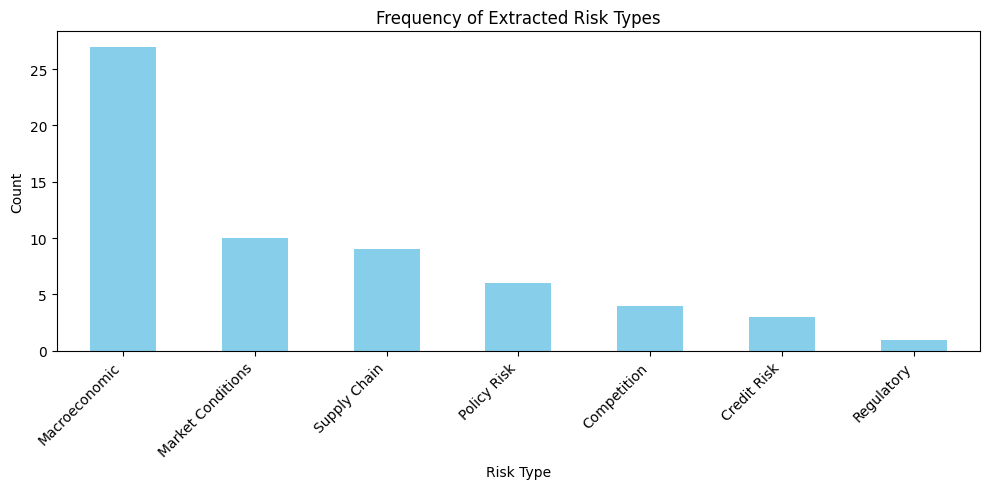

In [ ]:
plt.figure(figsize=(10, 5))
risk_counts.plot(kind="bar", color="skyblue")
plt.title("Frequency of Extracted Risk Types")
plt.xlabel("Risk Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [78]:
df_risks

,company,year,risk_type,risk_summary,confidence
0,Bank of America Corporation,2024,Credit Risk,Net charge-offs increased due to credit card s...,0.90
1,Linde plc,2023,Macroeconomic,The company acknowledges that some economies a...,0.90
2,AbbVie Inc.,2024,Market Conditions,The company noted that recent performance in a...,0.90
3,TE Connectivity plc,2023,Supply Chain,Company mentions that improving supply chains ...,0.90
4,The AES Corporation,2023,Policy Risk,The company is awaiting guidance from the Trea...,0.90
5,General Electric Company,2023,Supply Chain,The company acknowledges navigating a challeng...,0.95
6,Parker-Hannifin Corporation,2025,Market Conditions,The company notes continued delays in the expe...,0.90
7,The Kraft Heinz Company,2023,Competition,Competitors are promoting at a higher level th...,0.85
8,Johnson & Johnson,2023,Policy Risk,The company expressed concern about the Inflat...,0.90
9,PACCAR Inc,2025,Macroeconomic,The North American truck market is being affec...,0.90


***Informal Precision and Recall***

We checked several extracted rows by reading the original transcripts and comparing them with the model's output. The risk_type matched a real risk in every example we reviewed, so the informal precision was high. However, the transcripts often mentioned more than one risk, and the model only returned one main risk each time. This means the informal recall was low, which makes sense because we asked the model to pick only one dominant risk.

***Limitations and Systematic Errors***

1. The model reports only one risk even when the transcript contains several important risks.
2. Most risk labels are now consistent, but the model still chooses different dominant risks depending on phrasing.
3. Some summaries are short and miss smaller details, especially when the transcript covers many topics.
4. The model sometimes picks broad categories like “Macroeconomic,” even when the transcript includes more specific risks.
5. We used a limited number of transcripts, so the extracted risks may not represent the whole dataset.

### 6. Knowledge Graph / Network Construction

In [79]:
# df_risks has this structure:
# company | year | risk_type | risk_summary | confidence

# Initialize graph
G = nx.Graph()

# Add nodes and edges
for _, row in df_risks.iterrows():
    
    company = row["company"]
    risk = row["risk_type"]

    # Add company node (type=company)
    G.add_node(company, node_type="company")

    # Add risk node (type=risk)
    G.add_node(risk, node_type="risk")

    # Add edge between them
    G.add_edge(
        company,
        risk,
        year=row["year"],
        summary=row["risk_summary"],
        confidence=row["confidence"]
    )

print("Graph created successfully!")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


Graph created successfully!
Number of nodes: 65
Number of edges: 60


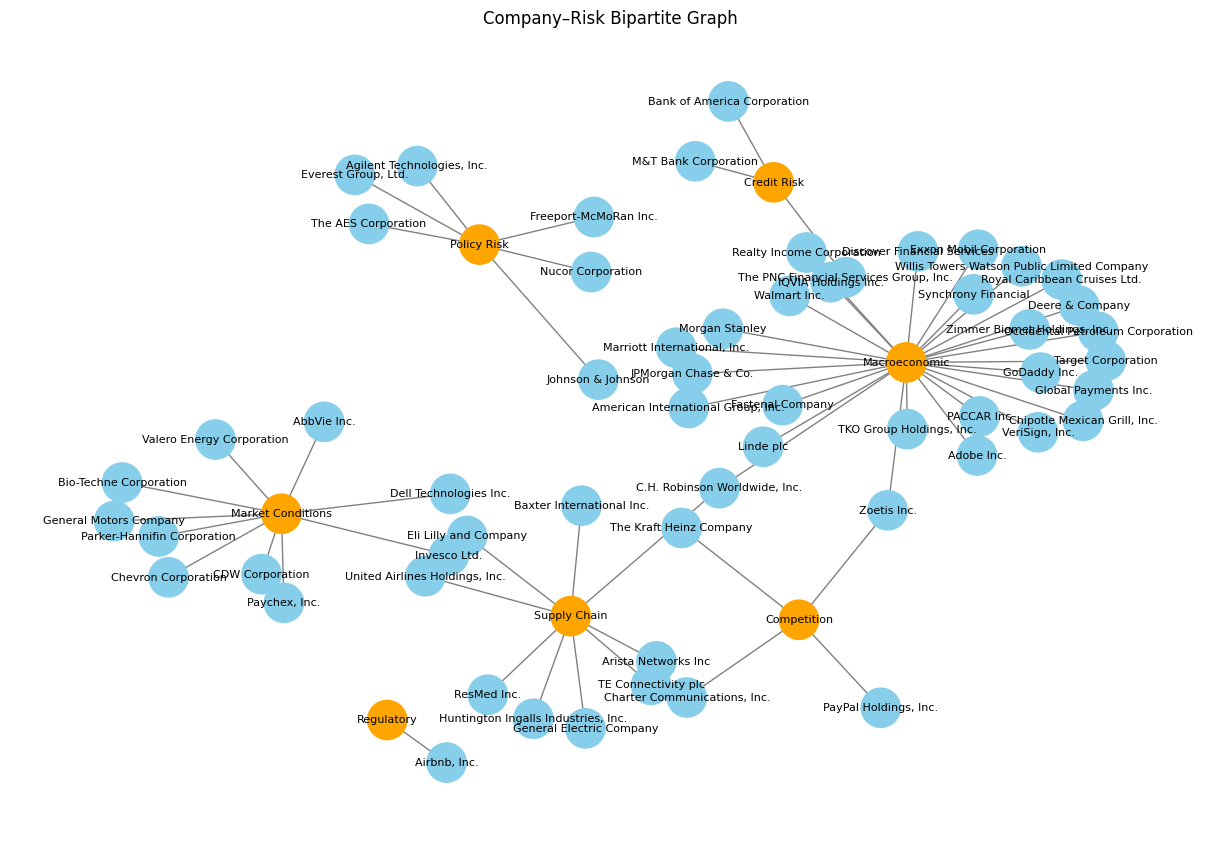

In [80]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, k=0.35, seed=42)

# Color companies blue, risks orange
colors = [
    "skyblue" if G.nodes[n]["node_type"] == "company" else "orange"
    for n in G.nodes()
]

nx.draw(
    G,
    pos,
    node_color=colors,
    with_labels=True,
    node_size=800,
    font_size=8,
    edge_color="gray"
)

plt.title("Company–Risk Bipartite Graph")
plt.show()


### 7. Network Analysis

##### 7.1 Degree Centrality

In [81]:
# Separate company and risk nodes
company_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "company"]
risk_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "risk"]

print("Companies:", len(company_nodes))
print("Risks:", len(risk_nodes))

# Compute degrees
deg = dict(G.degree())

# Risk degrees only
risk_deg = {n: deg[n] for n in risk_nodes}
company_deg = {n: deg[n] for n in company_nodes}

# Turn into DataFrames
df_risk_deg = pd.DataFrame(
    [{"risk_type": k, "degree": v} for k, v in risk_deg.items()]
).sort_values("degree", ascending=False)

df_company_deg = pd.DataFrame(
    [{"company": k, "degree": v} for k, v in company_deg.items()]
).sort_values("degree", ascending=False)

print("\nTop risk types by degree:")
display(df_risk_deg)

print("\nTop companies by degree:")
display(df_company_deg.head())

Companies: 58
Risks: 7

Top risk types by degree:


,risk_type,degree
1,Macroeconomic,27
2,Market Conditions,10
3,Supply Chain,9
4,Policy Risk,6
5,Competition,4
0,Credit Risk,3
6,Regulatory,1



Top companies by degree:


,company,degree
15,"C.H. Robinson Worldwide, Inc.",2
40,Zoetis Inc.,2
0,Bank of America Corporation,1
32,Adobe Inc.,1
33,"Huntington Ingalls Industries, Inc.",1


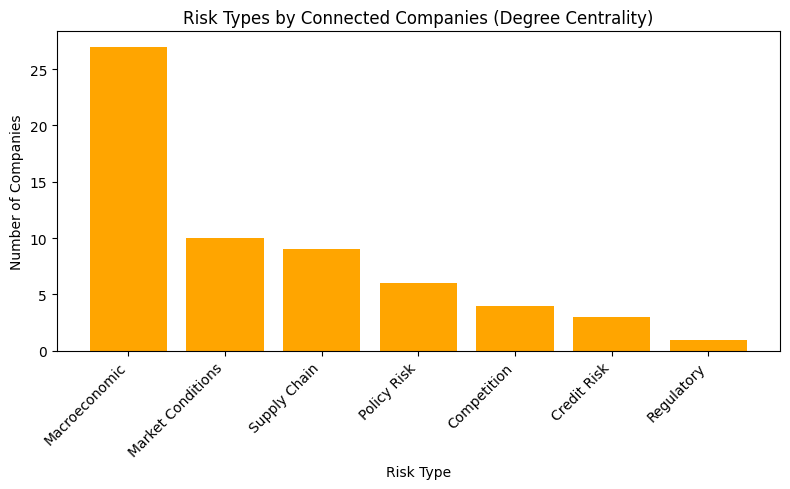

In [82]:
plt.figure(figsize=(8,5))
plt.bar(df_risk_deg["risk_type"], df_risk_deg["degree"], color="orange")
plt.title("Risk Types by Connected Companies (Degree Centrality)")
plt.xlabel("Risk Type")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 7.2 Risk–Risk Projection

In [83]:
# Project bipartite graph onto risk nodes
risk_graph = bipartite.weighted_projected_graph(G, risk_nodes)

print("Risk–Risk projection created.")
print("Nodes:", risk_graph.number_of_nodes())
print("Edges:", risk_graph.number_of_edges())


Risk–Risk projection created.
Nodes: 7
Edges: 2


In [84]:
# Extract risk-risk edges with weights
edges = [
    (u, v, d["weight"]) 
    for u, v, d in risk_graph.edges(data=True)
]

df_co = (
    pd.DataFrame(edges, columns=["risk_1", "risk_2", "weight"])
    .sort_values("weight", ascending=False)
)

print("\nTop Risk–Risk Co-occurrences:")
display(df_co.head(10))



Top Risk–Risk Co-occurrences:


,risk_1,risk_2,weight
0,Macroeconomic,Competition,1
1,Macroeconomic,Supply Chain,1


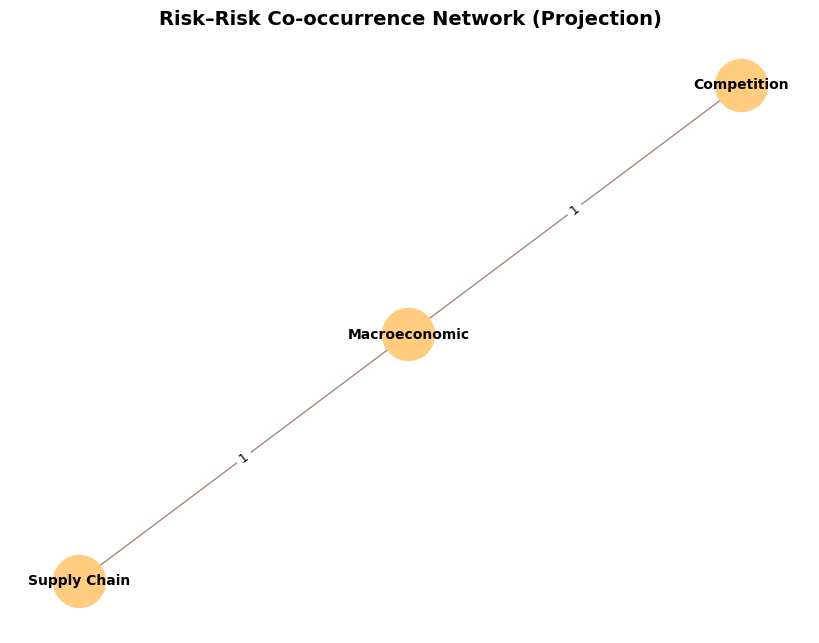

In [85]:
# --- Keep only connected nodes (so graph looks clean) ---
connected_nodes = set([u for u, v in risk_graph.edges()] + 
                      [v for u, v in risk_graph.edges()])

H = risk_graph.subgraph(connected_nodes)

# --- Layout ---
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(H, seed=42, k=0.22)

# --- Styling ---
node_color = "#FFCC80"   # warm amber
edge_color = "#A1887F"
edge_widths = [d['weight'] for _, _, d in H.edges(data=True)]

# --- Draw main network ---
nx.draw(
    H,
    pos,
    with_labels=True,
    node_color=node_color,
    node_size=1400,
    font_size=10,
    font_weight="bold",
    edge_color=edge_color,
    width=edge_widths,
)

# --- Draw edge labels (weights) ---
edge_labels = nx.get_edge_attributes(H, "weight")
nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=9)

plt.title("Risk–Risk Co-occurrence Network (Projection)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()


##### 7.3 Risk Type Per Year

In [86]:
graphs_by_year = {}
centrality_by_year = {}

for y in years_of_interest:
    print(f"\n==============================")
    print(f"   YEAR {y} NETWORK ANALYSIS")
    print(f"==============================")

    df_y = df_net[df_net["year"] == y].copy()
    print(f"Rows for {y}: {len(df_y)}")

    G_y, cent_y = build_bipartite_and_centrality(df_y)
    graphs_by_year[y] = G_y
    centrality_by_year[y] = cent_y

    print(f"Nodes: {G_y.number_of_nodes()},  Edges: {G_y.number_of_edges()}")

    # Top 6 risk types for that year
    top_risks_y = (
        cent_y[cent_y["node_type"] == "risk"]
        .sort_values("degree_centrality", ascending=False)
        .head(6)
        .reset_index(drop=True)
    )

    print(f"\nTop Risk Types in {y}:")
    display(top_risks_y[["node", "degree", "degree_centrality", "betweenness_centrality"]])



   YEAR 2023 NETWORK ANALYSIS
Rows for 2023: 31
Nodes: 37,  Edges: 31

Top Risk Types in 2023:


,node,degree,degree_centrality,betweenness_centrality
0,Macroeconomic,14,0.388889,0.144444
1,Supply Chain,7,0.194444,0.033333
2,Market Conditions,5,0.138889,0.015873
3,Policy Risk,2,0.055556,0.001587
4,Competition,2,0.055556,0.001587
5,Credit Risk,1,0.027778,0.000000



   YEAR 2024 NETWORK ANALYSIS
Rows for 2024: 19
Nodes: 24,  Edges: 19

Top Risk Types in 2024:


,node,degree,degree_centrality,betweenness_centrality
0,Macroeconomic,6,0.260870,0.177866
1,Market Conditions,5,0.217391,0.173913
2,Credit Risk,3,0.130435,0.011858
3,Policy Risk,2,0.086957,0.003953
4,Regulatory,1,0.043478,0.000000
5,Competition,1,0.043478,0.000000



   YEAR 2025 NETWORK ANALYSIS
Rows for 2025: 10
Nodes: 13,  Edges: 10

Top Risk Types in 2025:


,node,degree,degree_centrality,betweenness_centrality
0,Market Conditions,4,0.333333,0.090909
1,Macroeconomic,4,0.333333,0.090909
2,Policy Risk,2,0.166667,0.015152


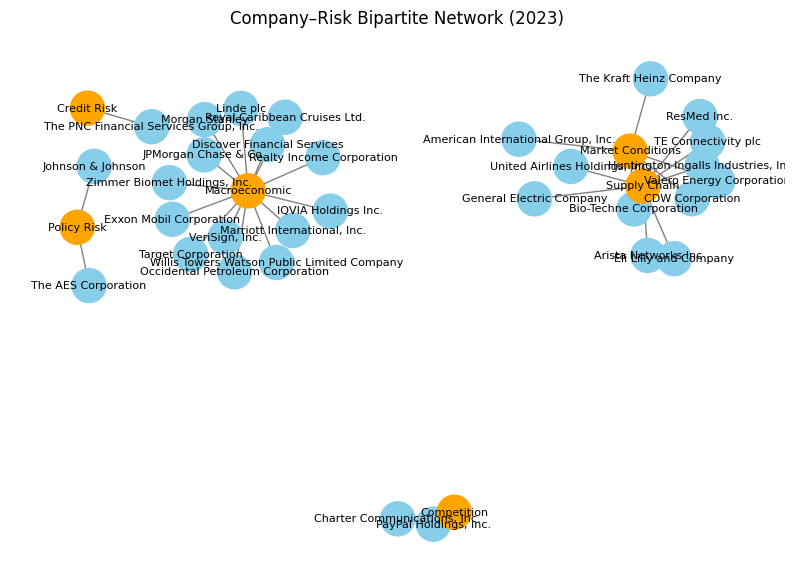

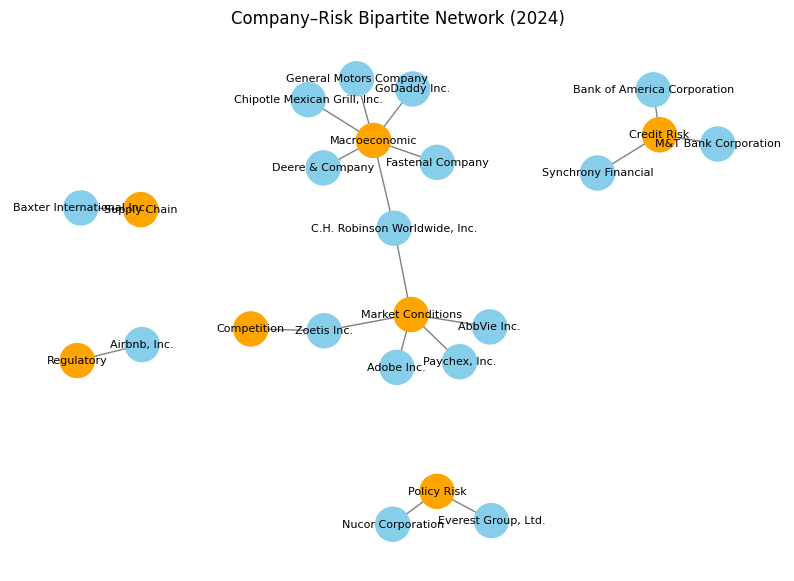

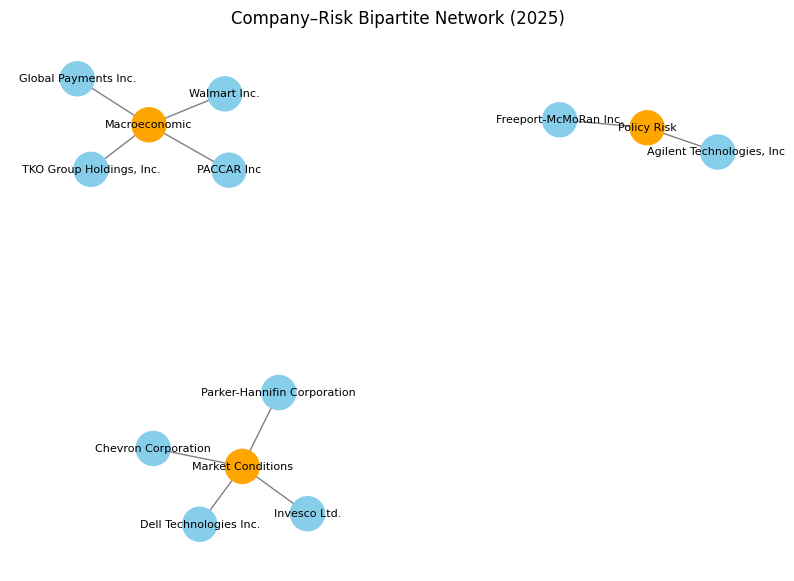

In [87]:
def plot_yearly_bipartite_graph(G, year):
    plt.figure(figsize=(10, 7))
    plt.title(f"Company–Risk Bipartite Network ({year})")

    pos = nx.spring_layout(G, k=0.35, seed=42)

    # Colors: company=blue, risk=orange
    colors = [
        "skyblue" if G.nodes[n]["node_type"] == "company" else "orange"
        for n in G.nodes()
    ]

    nx.draw(
        G, pos,
        with_labels=True,
        node_color=colors,
        node_size=600,
        font_size=8,
        edge_color="gray"
    )

    plt.show()


# ----- Plot every year -----
for y in graphs_by_year:
    plot_yearly_bipartite_graph(graphs_by_year[y], y)


In [ ]:
# df_risks.to_csv("extracted_risks.csv", index=False)
# print("saved: extracted_risks.csv")

saved: extracted_risks.csv


***References***

Kurry. (2024). S&P 500 earnings call transcripts (2005–2025) [Dataset]. Hugging Face. https://huggingface.co/datasets/kurry/sp500_earnings_transcripts